<a href="https://colab.research.google.com/github/Cicel599/patient-appointment-no-show-prediction/blob/main/Notebooks/Notebook_03_SHAP_and_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
## Notebook 03 — SHAP and LIME Explainability Analysis
### COM748 MSc Research Project — Ulster University

**Reference:** Hathaway et al. (2025) — Top predictors: lead_time_days, prior_noshow_ratio  
**Model analysed:** XGBoost (best performing model from Notebook 02)

---
### Notebook Structure
1. Imports and setup
2. Load model and data
3. SHAP Analysis
   - 3.1 Global feature importance (bar chart)
   - 3.2 SHAP summary beeswarm plot
   - 3.3 SHAP dependence plots (top 3 features)
   - 3.4 Individual waterfall charts (high-risk and low-risk patients)
4. LIME Analysis
   - 4.1 LIME on a stratified sample of 100 predictions
   - 4.2 Average LIME feature importance
5. SHAP vs LIME Consistency Comparison
   - 5.1 Spearman rank correlation
   - 5.2 Side-by-side ranking comparison
6. Key findings summary

---
### Why both SHAP and LIME?
Bussmann et al. (2021) found SHAP and LIME produce different feature rankings on financial risk models.  
No study has tested this for healthcare no-show prediction.  
This comparison is an **original contribution** of this dissertation.

---
## 1. Imports and Setup

In [ ]:
# ── Install if running on Google Colab ───────────────────────────────────
# Uncomment the lines below if on Colab
!pip install shap lime xgboost -q

# ── Standard ──────────────────────────────────────────────────────────────
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Explainability ────────────────────────────────────────────────────────
import shap
from lime import lime_tabular

# ── Stats ─────────────────────────────────────────────────────────────────
from scipy.stats import spearmanr

# ── Plot settings ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.family'      : 'sans-serif',
    'font.size'        : 11
})

RANDOM_STATE  = 42
LIME_SAMPLE_N = 100   # Number of predictions for LIME analysis

np.random.seed(RANDOM_STATE)

print('=' * 60)
print('All libraries loaded successfully')
print('=' * 60)
print(f'SHAP version : {shap.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All libraries loaded successfully
SHAP version : 0.52.0


---
## 2. Load Model and Data

In [ ]:
# ── Paths — update if using Google Drive ─────────────────────────────────
DATA_DIR   = 'data_processed'    # Change to Drive path if on Colab
MODELS_DIR = 'trained_models'    # Change to Drive path if on Colab

# ── Load preprocessed test data ───────────────────────────────────────────
X_test         = joblib.load(f'{DATA_DIR}/X_test.pkl')
y_test         = joblib.load(f'{DATA_DIR}/y_test.pkl')
X_train        = joblib.load(f'{DATA_DIR}/X_train_balanced.pkl')
FEATURE_COLS   = joblib.load(f'{DATA_DIR}/feature_columns.pkl')

# ── Load XGBoost model ────────────────────────────────────────────────────
xgb_model = joblib.load(f'{MODELS_DIR}/xgboost.pkl')

# ── Convert to DataFrame for easier handling ──────────────────────────────
X_test_df  = pd.DataFrame(X_test,  columns=FEATURE_COLS)
X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
y_test_arr = np.array(y_test)

print('=' * 60)
print('Data and Model Loaded')
print('=' * 60)
print(f'Test set shape  : {X_test_df.shape}')
print(f'Train set shape : {X_train_df.shape}')
print(f'Features ({len(FEATURE_COLS)}):')
for i, f in enumerate(FEATURE_COLS):
    print(f'  [{i:02d}] {f}')

Data and Model Loaded
Test set shape  : (22105, 17)
Train set shape : (141130, 17)
Features (17):
  [00] age
  [01] gender_binary
  [02] scholarship
  [03] hypertension
  [04] diabetes
  [05] alcoholism
  [06] disability
  [07] sms_received
  [08] lead_time_days
  [09] scheduled_hour
  [10] prior_noshow_ratio
  [11] dow_0
  [12] dow_1
  [13] dow_2
  [14] dow_3
  [15] dow_4
  [16] dow_5


---
## 3. SHAP Analysis

**SHAP (SHapley Additive exPlanations)** — Lundberg & Lee (2017)  
Assigns each feature an exact contribution value for each prediction,  
based on cooperative game theory (Shapley values).  

We use **TreeExplainer**, which is optimised for tree-based models like XGBoost.  
It computes exact SHAP values rather than approximations — fast and accurate.

In [ ]:
# ── Compute SHAP values ───────────────────────────────────────────────────
print('Computing SHAP values with TreeExplainer...')
print('(This runs on the full test set — may take 1-2 minutes)')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# shap_values shape: (n_samples, n_features)
# Positive SHAP value = pushes prediction toward no-show (class 1)
# Negative SHAP value = pushes prediction toward attended (class 0)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Expected value    : {explainer.expected_value:.4f}')
print('(Expected value = base rate = mean prediction before seeing any features)')
print('\nSHAP computation complete.')

Computing SHAP values with TreeExplainer...
(This runs on the full test set — may take 1-2 minutes)
SHAP values shape : (22105, 17)
Expected value    : 0.0046
(Expected value = base rate = mean prediction before seeing any features)

SHAP computation complete.


### 3.1 Global Feature Importance
Average absolute SHAP value per feature — shows which features matter most overall.

In [ ]:
# ── Mean absolute SHAP values ─────────────────────────────────────────────
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({
    'Feature'         : FEATURE_COLS,
    'Mean |SHAP|'     : mean_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('=' * 60)
print('SHAP Feature Importance — Global Ranking')
print('=' * 60)
print(shap_df.to_string(index=False))

print(f'\nTop predictor    : {shap_df.iloc[0]["Feature"]}')
print(f'Second predictor : {shap_df.iloc[1]["Feature"]}')
print(f'Third predictor  : {shap_df.iloc[2]["Feature"]}')
print('\nHathaway et al. (2025) top predictors: lead_time_days, prior_noshow_ratio')
print('Compare whether the same features emerge on the Brazilian public dataset.')

SHAP Feature Importance — Global Ranking
           Feature  Mean |SHAP|
    lead_time_days     0.975807
               age     0.309317
    scheduled_hour     0.154765
prior_noshow_ratio     0.133526
      sms_received     0.055614
             dow_1     0.027375
     gender_binary     0.022193
             dow_0     0.013276
      hypertension     0.012339
             dow_4     0.011631
        disability     0.009961
             dow_2     0.008377
             dow_3     0.007327
       scholarship     0.004126
          diabetes     0.003103
        alcoholism     0.001745
             dow_5     0.000000

Top predictor    : lead_time_days
Second predictor : age
Third predictor  : scheduled_hour

Hathaway et al. (2025) top predictors: lead_time_days, prior_noshow_ratio
Compare whether the same features emerge on the Brazilian public dataset.


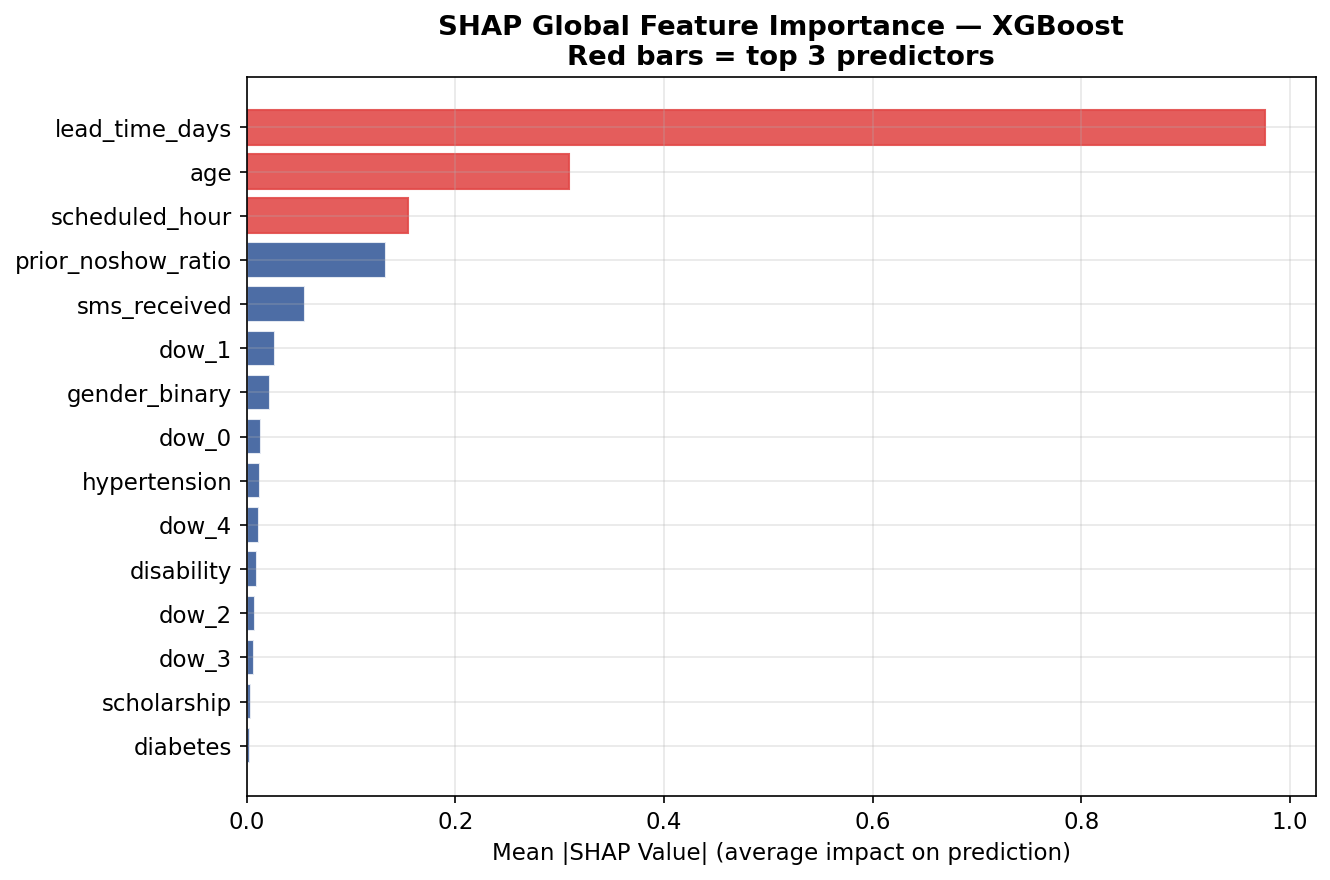

Figure saved: fig_12_shap_importance_bar.png


In [ ]:
# ── SHAP importance bar chart ─────────────────────────────────────────────
top_n = min(15, len(FEATURE_COLS))  # Show top 15 features
top_shap = shap_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top_shap['Feature'][::-1],
    top_shap['Mean |SHAP|'][::-1],
    color='#2E5496', alpha=0.85, edgecolor='white'
)

# Highlight top 3
for i, bar in enumerate(bars):
    if i >= top_n - 3:
        bar.set_color('#E24B4A')
        bar.set_alpha(0.9)

ax.set_xlabel('Mean |SHAP Value| (average impact on prediction)')
ax.set_title('SHAP Global Feature Importance — XGBoost\n'
             'Red bars = top 3 predictors', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_shap_importance_bar.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_12_shap_importance_bar.png')

### 3.2 SHAP Summary Beeswarm Plot
Shows the direction and magnitude of each feature's impact.  
Red = high feature value, Blue = low feature value.  
Right side = pushes toward no-show, Left side = pushes toward attended.

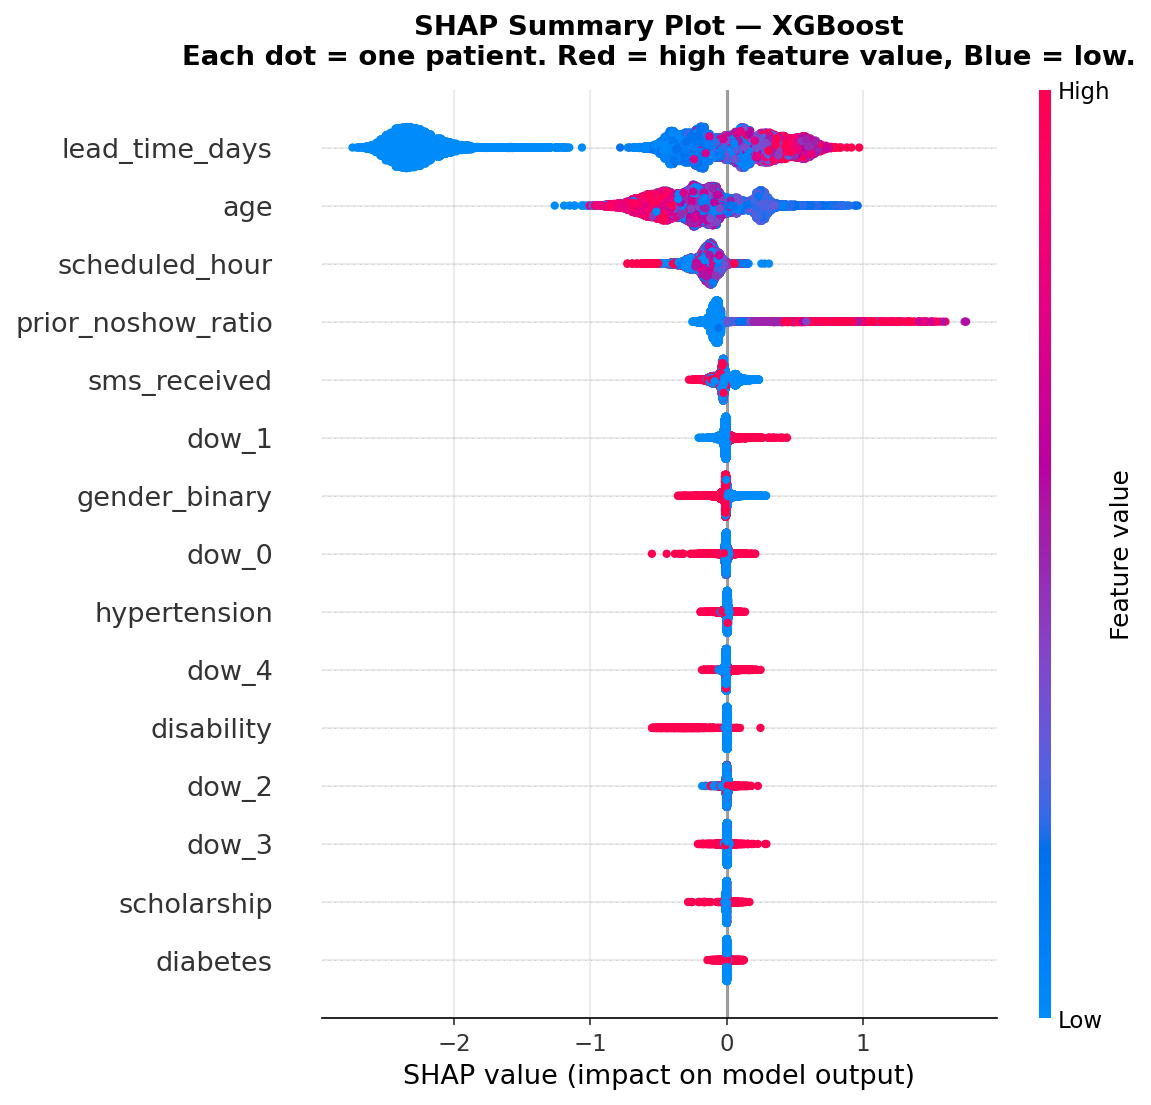

Figure saved: fig_13_shap_beeswarm.png


In [ ]:
# ── SHAP beeswarm plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=FEATURE_COLS,
    max_display=15,
    show=False
)

plt.title('SHAP Summary Plot — XGBoost\n'
          'Each dot = one patient. Red = high feature value, Blue = low.',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_13_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_13_shap_beeswarm.png')

### 3.3 SHAP Dependence Plots — Top 3 Features
Shows how SHAP value changes as a feature value increases.  
Colour shows interaction with a second feature (auto-selected by SHAP).

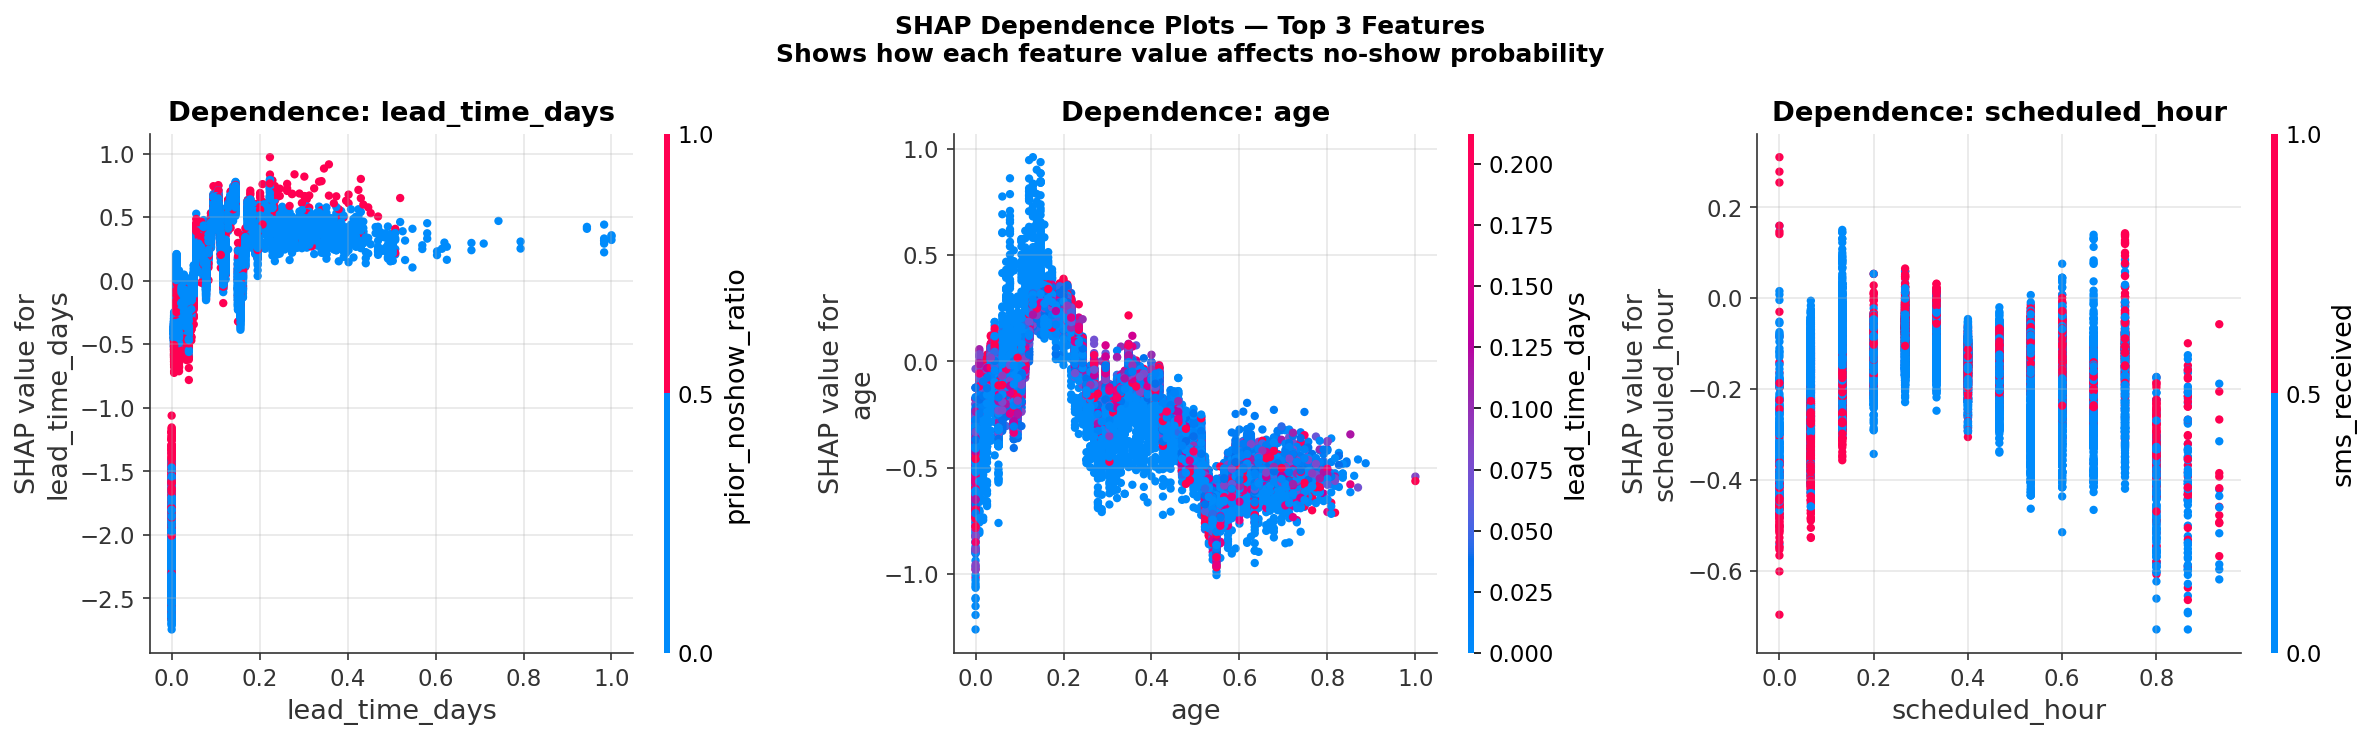

Figure saved: fig_14_shap_dependence.png


In [ ]:
# ── Dependence plots for top 3 features ───────────────────────────────────
top3_features = shap_df['Feature'].iloc[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, top3_features):
    feat_idx = FEATURE_COLS.index(feature)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_df,
        feature_names=FEATURE_COLS,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence: {feature}', fontweight='bold')

fig.suptitle('SHAP Dependence Plots — Top 3 Features\n'
             'Shows how each feature value affects no-show probability',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_14_shap_dependence.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_14_shap_dependence.png')

### 3.4 Individual Waterfall Charts
Shows the exact contribution of each feature for specific patients.  
We select one high-risk (predicted no-show) and one low-risk (predicted attendee) patient.

In [ ]:
# ── Get model predictions on test set ────────────────────────────────────
y_prob = xgb_model.predict_proba(X_test_df)[:, 1]
y_pred = xgb_model.predict(X_test_df)

# ── Select representative patients ────────────────────────────────────────
# High-risk: true no-show correctly predicted with high confidence
tp_mask   = (y_pred == 1) & (y_test_arr == 1)  # True positives
tp_probs  = y_prob.copy()
tp_probs[~tp_mask] = 0
high_risk_idx = tp_probs.argmax()  # Highest confidence true positive

# Low-risk: true attendee correctly predicted with high confidence
tn_mask   = (y_pred == 0) & (y_test_arr == 0)  # True negatives
tn_probs  = y_prob.copy()
tn_probs[tn_mask] = 1 - tn_probs[tn_mask]
tn_probs[~tn_mask] = 1
low_risk_idx = tn_probs.argmin()

print(f'High-risk patient (index {high_risk_idx}):'
      f' predicted prob = {y_prob[high_risk_idx]:.3f}, actual = {y_test_arr[high_risk_idx]}')
print(f'Low-risk  patient (index {low_risk_idx}):'
      f' predicted prob = {y_prob[low_risk_idx]:.3f}, actual = {y_test_arr[low_risk_idx]}')

High-risk patient (index 10798): predicted prob = 0.888, actual = 1
Low-risk  patient (index 13198): predicted prob = 0.500, actual = 0


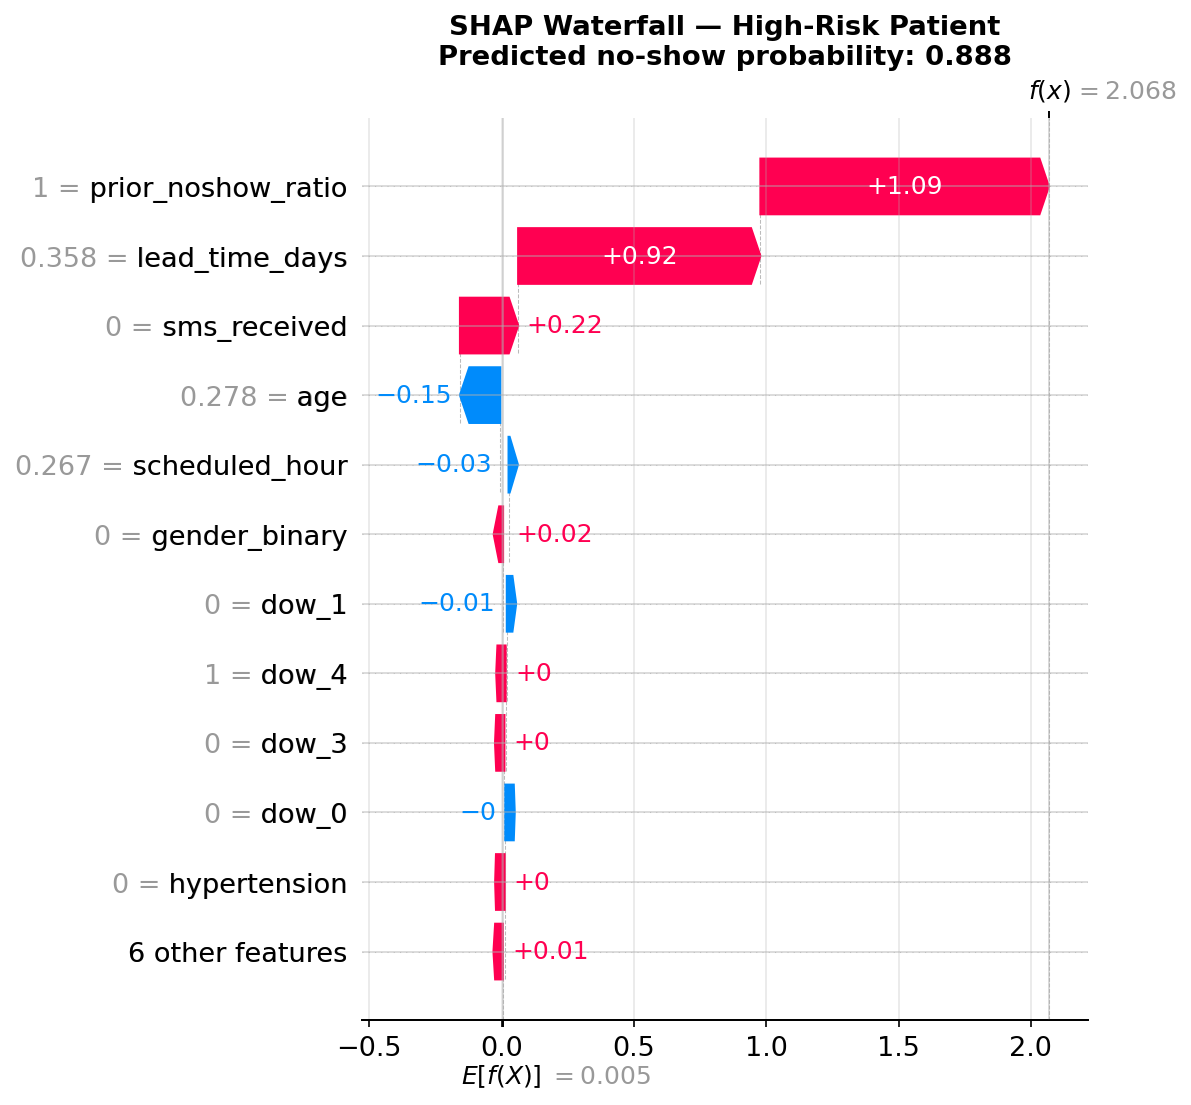

Figure saved: fig_15_shap_waterfall_high_risk.png


In [ ]:
# ── Waterfall chart — High-risk patient ───────────────────────────────────
shap_exp = shap.Explanation(
    values         = shap_values[high_risk_idx],
    base_values    = explainer.expected_value,
    data           = X_test_df.iloc[high_risk_idx].values,
    feature_names  = FEATURE_COLS
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — High-Risk Patient\n'
          f'Predicted no-show probability: {y_prob[high_risk_idx]:.3f}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_15_shap_waterfall_high_risk.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_15_shap_waterfall_high_risk.png')

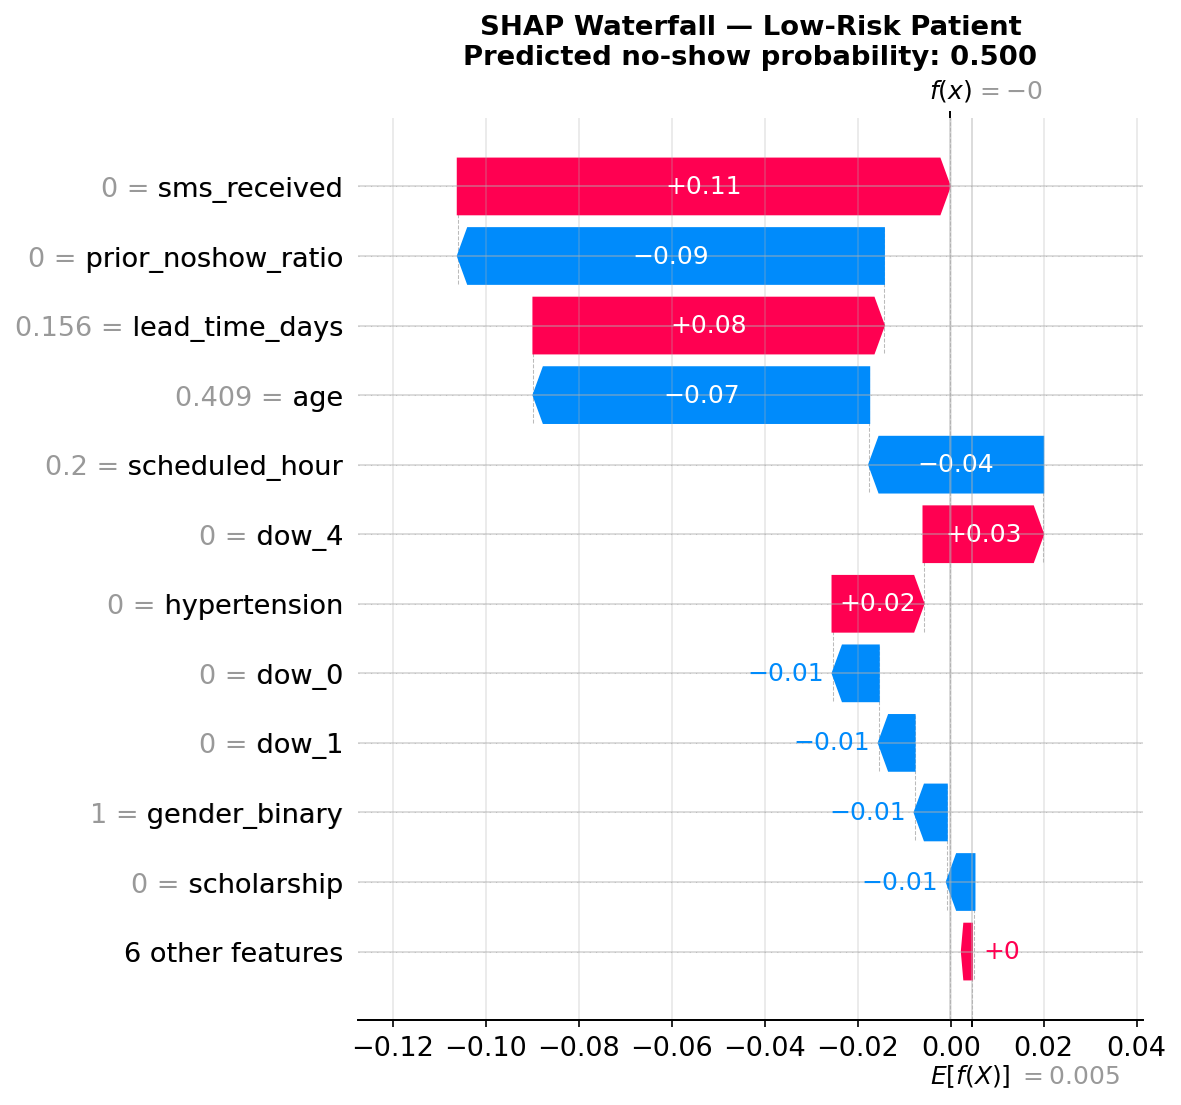

Figure saved: fig_16_shap_waterfall_low_risk.png


In [ ]:
# ── Waterfall chart — Low-risk patient ────────────────────────────────────
shap_exp_low = shap.Explanation(
    values         = shap_values[low_risk_idx],
    base_values    = explainer.expected_value,
    data           = X_test_df.iloc[low_risk_idx].values,
    feature_names  = FEATURE_COLS
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_exp_low, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Low-Risk Patient\n'
          f'Predicted no-show probability: {y_prob[low_risk_idx]:.3f}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_16_shap_waterfall_low_risk.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_16_shap_waterfall_low_risk.png')

---
## 4. LIME Analysis

**LIME (Local Interpretable Model-agnostic Explanations)** — Ribeiro et al. (2016)  
For each individual prediction, LIME:
1. Creates slightly perturbed versions of that patient's data
2. Asks the model to predict on those perturbed versions
3. Fits a simple linear model to those predictions
4. Uses that linear model's coefficients as the feature importance

LIME is **local and approximate** (vs SHAP which is global and exact).  
Applied to a stratified sample of 100 predictions to keep runtime manageable.

In [ ]:
# ── Set up LIME explainer ─────────────────────────────────────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data   = X_train_df.values,
    feature_names   = FEATURE_COLS,
    class_names     = ['Attended', 'No-Show'],
    mode            = 'classification',
    random_state    = RANDOM_STATE,
    discretize_continuous = True
)

print('LIME explainer initialised.')
print(f'Training background: {X_train_df.shape[0]:,} samples')
print(f'LIME will analyse {LIME_SAMPLE_N} individual test predictions')

LIME explainer initialised.
Training background: 141,130 samples
LIME will analyse 100 individual test predictions


In [ ]:
# ── Stratified sample of 100 predictions ─────────────────────────────────
# Stratified: 50 no-shows, 50 attended — ensures both classes are explained
np.random.seed(RANDOM_STATE)

noshow_idx   = np.where(y_test_arr == 1)[0]
attended_idx = np.where(y_test_arr == 0)[0]

sample_noshow   = np.random.choice(noshow_idx,   size=50, replace=False)
sample_attended = np.random.choice(attended_idx, size=50, replace=False)
sample_idx      = np.concatenate([sample_noshow, sample_attended])

print(f'Stratified sample: {len(sample_noshow)} no-shows + {len(sample_attended)} attended')
print(f'Total predictions to explain: {len(sample_idx)}')
print('\nRunning LIME — this may take 3-5 minutes...')

# ── Run LIME on each sample ───────────────────────────────────────────────
lime_importances = {feat: [] for feat in FEATURE_COLS}

for i, idx in enumerate(sample_idx):
    if (i + 1) % 20 == 0:
        print(f'  Explained {i+1}/{len(sample_idx)} predictions...')

    exp = lime_explainer.explain_instance(
        data_row       = X_test_df.iloc[idx].values,
        predict_fn     = xgb_model.predict_proba,
        num_features   = len(FEATURE_COLS),
        labels         = (1,)   # Explain the no-show class
    )

    # Collect feature weights for this prediction
    for feat_name, weight in exp.as_list(label=1):
        # LIME names are like 'lead_time_days > 5.00' — extract base name
        base_name = None
        for col in FEATURE_COLS:
            if col in feat_name:
                base_name = col
                break
        if base_name:
            lime_importances[base_name].append(abs(weight))

print('\nLIME analysis complete.')

Stratified sample: 50 no-shows + 50 attended
Total predictions to explain: 100

Running LIME — this may take 3-5 minutes...
  Explained 20/100 predictions...
  Explained 40/100 predictions...
  Explained 60/100 predictions...
  Explained 80/100 predictions...
  Explained 100/100 predictions...

LIME analysis complete.


### 4.2 Average LIME Feature Importance

In [ ]:
# ── Aggregate LIME importances ────────────────────────────────────────────
lime_avg = {feat: np.mean(vals) if vals else 0
            for feat, vals in lime_importances.items()}

lime_df = pd.DataFrame({
    'Feature'         : list(lime_avg.keys()),
    'Mean |LIME|'     : list(lime_avg.values())
}).sort_values('Mean |LIME|', ascending=False).reset_index(drop=True)

print('=' * 60)
print('LIME Feature Importance — Average over 100 predictions')
print('=' * 60)
print(lime_df.to_string(index=False))

print(f'\nLIME top predictor    : {lime_df.iloc[0]["Feature"]}')
print(f'LIME second predictor : {lime_df.iloc[1]["Feature"]}')
print(f'LIME third predictor  : {lime_df.iloc[2]["Feature"]}')

LIME Feature Importance — Average over 100 predictions
           Feature  Mean |LIME|
    lead_time_days     0.038369
        disability     0.028723
prior_noshow_ratio     0.018955
               age     0.018154
             dow_5     0.012631
    scheduled_hour     0.008305
      sms_received     0.007104
        alcoholism     0.003792
          diabetes     0.002890
       scholarship     0.002300
             dow_2     0.002195
             dow_3     0.001972
             dow_4     0.001775
             dow_0     0.001716
      hypertension     0.001698
     gender_binary     0.001410
             dow_1     0.001374

LIME top predictor    : lead_time_days
LIME second predictor : disability
LIME third predictor  : prior_noshow_ratio


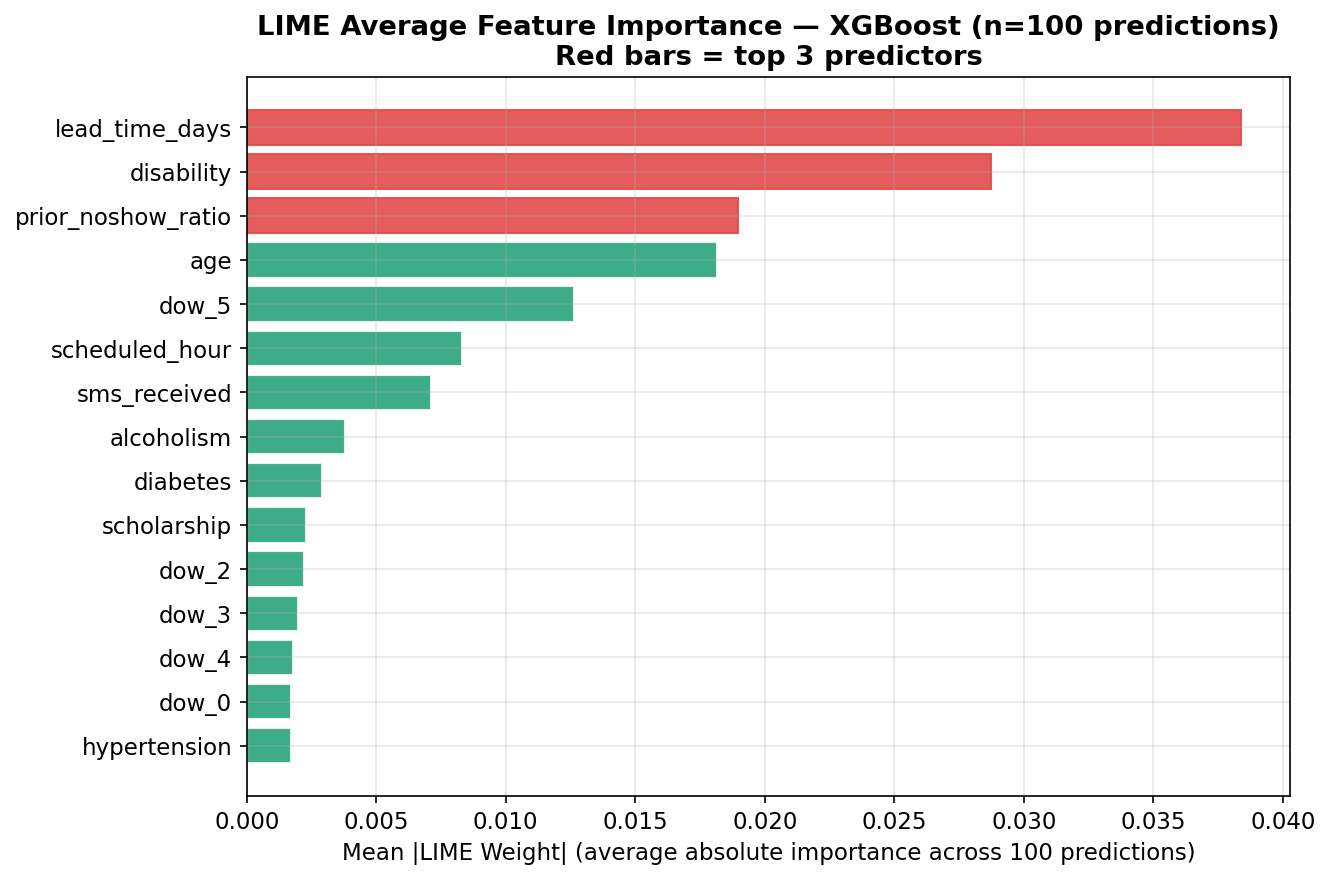

Figure saved: fig_17_lime_importance_bar.png


In [ ]:
# ── LIME importance bar chart ─────────────────────────────────────────────
top_lime = lime_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top_lime['Feature'][::-1],
    top_lime['Mean |LIME|'][::-1],
    color='#1D9E75', alpha=0.85, edgecolor='white'
)

for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color('#E24B4A')
        bar.set_alpha(0.9)

ax.set_xlabel('Mean |LIME Weight| (average absolute importance across 100 predictions)')
ax.set_title('LIME Average Feature Importance — XGBoost (n=100 predictions)\n'
             'Red bars = top 3 predictors', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_17_lime_importance_bar.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_17_lime_importance_bar.png')

Generating LIME explanation for high-risk patient...


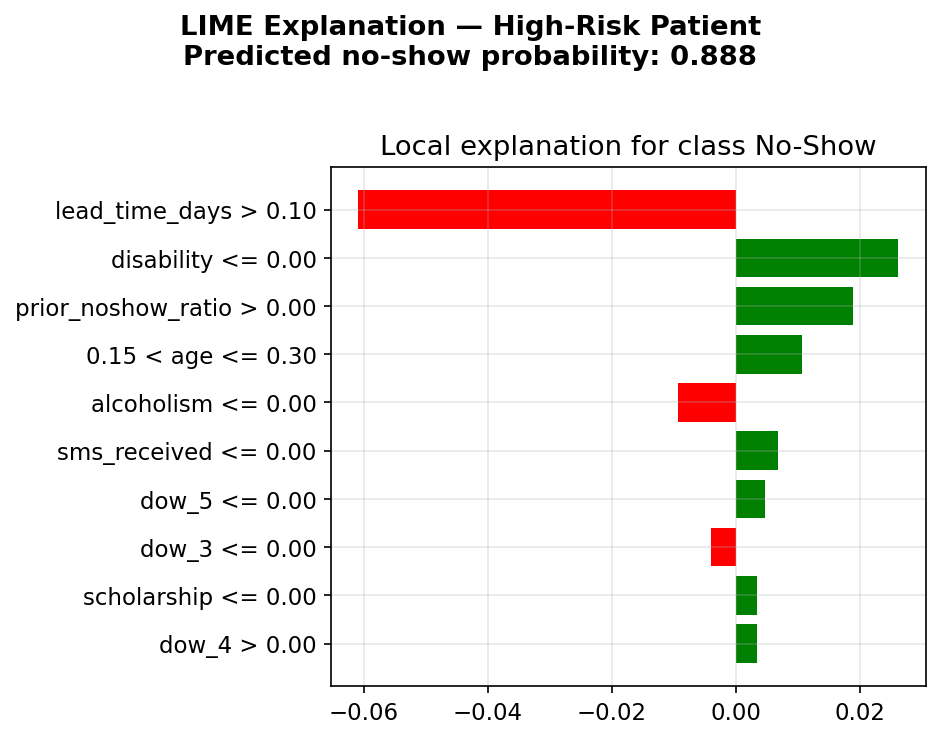

Figure saved: fig_18_lime_high_risk.png


In [ ]:
# ── LIME individual explanation — High-risk patient ───────────────────────
print('Generating LIME explanation for high-risk patient...')

lime_exp_high = lime_explainer.explain_instance(
    data_row   = X_test_df.iloc[high_risk_idx].values,
    predict_fn = xgb_model.predict_proba,
    num_features = 10,
    labels     = (1,)
)

fig = lime_exp_high.as_pyplot_figure(label=1)
fig.suptitle(f'LIME Explanation — High-Risk Patient\n'
             f'Predicted no-show probability: {y_prob[high_risk_idx]:.3f}',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_18_lime_high_risk.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_18_lime_high_risk.png')

---
## 5. SHAP vs LIME Consistency Comparison

**Research question:** Do SHAP and LIME agree on which features are most important?  

Bussmann et al. (2021) found disagreement in financial risk models.  
This is the first study to test this in the no-show prediction domain.  

We measure agreement using **Spearman rank correlation**:  
- ρ close to +1.0 = strong agreement (same features ranked similarly)
- ρ close to 0 = no agreement
- ρ close to -1.0 = opposite rankings

In [ ]:
# ── Align SHAP and LIME rankings ──────────────────────────────────────────
# SHAP: mean absolute SHAP values (already computed)
shap_rank_df = shap_df.set_index('Feature')['Mean |SHAP|']

# LIME: mean absolute LIME weights (already computed)
lime_rank_df = lime_df.set_index('Feature')['Mean |LIME|']

# Align on common features
common_features = [f for f in FEATURE_COLS
                   if f in shap_rank_df.index and f in lime_rank_df.index
                   and lime_rank_df[f] > 0]

shap_vals_aligned = shap_rank_df[common_features].values
lime_vals_aligned = lime_rank_df[common_features].values

# Spearman rank correlation
rho, pval = spearmanr(shap_vals_aligned, lime_vals_aligned)

print('=' * 60)
print('SHAP vs LIME — Spearman Rank Correlation')
print('=' * 60)
print(f'Features compared : {len(common_features)}')
print(f'Spearman rho (ρ)  : {rho:.4f}')
print(f'p-value           : {pval:.6f}')
print()

if rho >= 0.8:
    interpretation = 'STRONG agreement — SHAP and LIME produce consistent rankings.'
    conclusion = 'This validates SHAP conclusions for this dataset.'
elif rho >= 0.6:
    interpretation = 'MODERATE agreement — mostly consistent with some differences.'
    conclusion = 'SHAP and LIME broadly agree but differ on some mid-ranked features.'
elif rho >= 0.4:
    interpretation = 'WEAK agreement — notable differences between frameworks.'
    conclusion = 'Results depend on which XAI framework is used — warrants caution.'
else:
    interpretation = 'POOR agreement — SHAP and LIME disagree substantially.'
    conclusion = 'Consistent with Bussmann et al. (2021) findings in finance.'

print(f'Interpretation    : {interpretation}')
print(f'Conclusion        : {conclusion}')

SHAP vs LIME — Spearman Rank Correlation
Features compared : 17
Spearman rho (ρ)  : 0.2108
p-value           : 0.416750

Interpretation    : POOR agreement — SHAP and LIME disagree substantially.
Conclusion        : Consistent with Bussmann et al. (2021) findings in finance.


### 5.2 Side-by-Side Ranking Comparison

In [ ]:
# ── Feature rank comparison table ─────────────────────────────────────────
shap_ranks = {f: i+1 for i, f in enumerate(shap_df['Feature'])}
lime_ranks = {f: i+1 for i, f in enumerate(lime_df['Feature'])}

comparison_df = pd.DataFrame({
    'Feature'      : FEATURE_COLS,
    'SHAP Rank'    : [shap_ranks.get(f, '-') for f in FEATURE_COLS],
    'LIME Rank'    : [lime_ranks.get(f, '-') for f in FEATURE_COLS],
})

# Add rank difference
comparison_df['Rank Diff'] = comparison_df.apply(
    lambda row: abs(int(row['SHAP Rank']) - int(row['LIME Rank']))
    if isinstance(row['SHAP Rank'], int) and isinstance(row['LIME Rank'], int)
    else '-', axis=1
)

comparison_df = comparison_df.sort_values('SHAP Rank')

print('=' * 60)
print('SHAP vs LIME — Feature Rank Comparison')
print('=' * 60)
print(comparison_df.to_string(index=False))
print(f'\nSpearman ρ = {rho:.4f} | {interpretation}')

SHAP vs LIME — Feature Rank Comparison
           Feature  SHAP Rank  LIME Rank  Rank Diff
    lead_time_days          1          1          0
               age          2          4          2
    scheduled_hour          3          6          3
prior_noshow_ratio          4          3          1
      sms_received          5          7          2
             dow_1          6         17         11
     gender_binary          7         16          9
             dow_0          8         14          6
      hypertension          9         15          6
             dow_4         10         13          3
        disability         11          2          9
             dow_2         12         11          1
             dow_3         13         12          1
       scholarship         14         10          4
          diabetes         15          9          6
        alcoholism         16          8          8
             dow_5         17          5         12

Spearman ρ = 0.2108 | PO

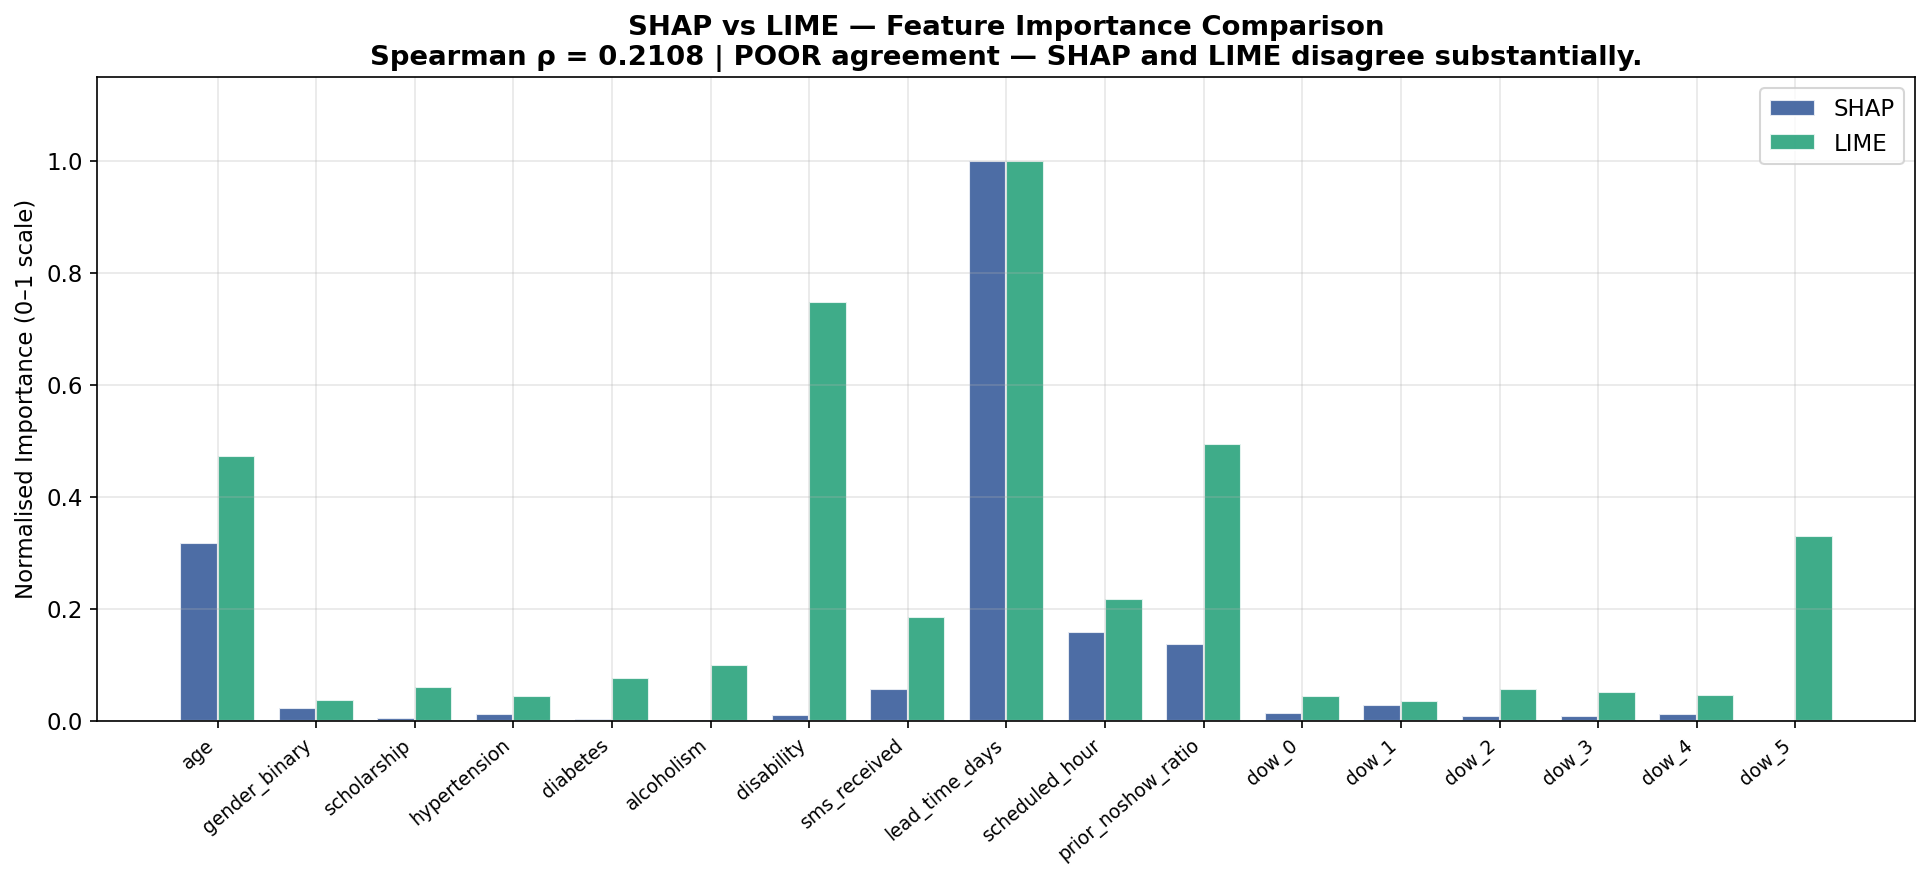

Figure saved: fig_19_shap_vs_lime_comparison.png


In [ ]:
# ── Side-by-side bar chart comparison ─────────────────────────────────────
# Normalise both to 0-1 scale for visual comparison
shap_norm = shap_vals_aligned / shap_vals_aligned.max()
lime_norm = lime_vals_aligned / lime_vals_aligned.max()

x     = np.arange(len(common_features))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, shap_norm, width,
               label='SHAP', color='#2E5496', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, lime_norm, width,
               label='LIME', color='#1D9E75', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(common_features, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Normalised Importance (0–1 scale)')
ax.set_title(f'SHAP vs LIME — Feature Importance Comparison\n'
             f'Spearman ρ = {rho:.4f} | {interpretation}',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('fig_19_shap_vs_lime_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_19_shap_vs_lime_comparison.png')

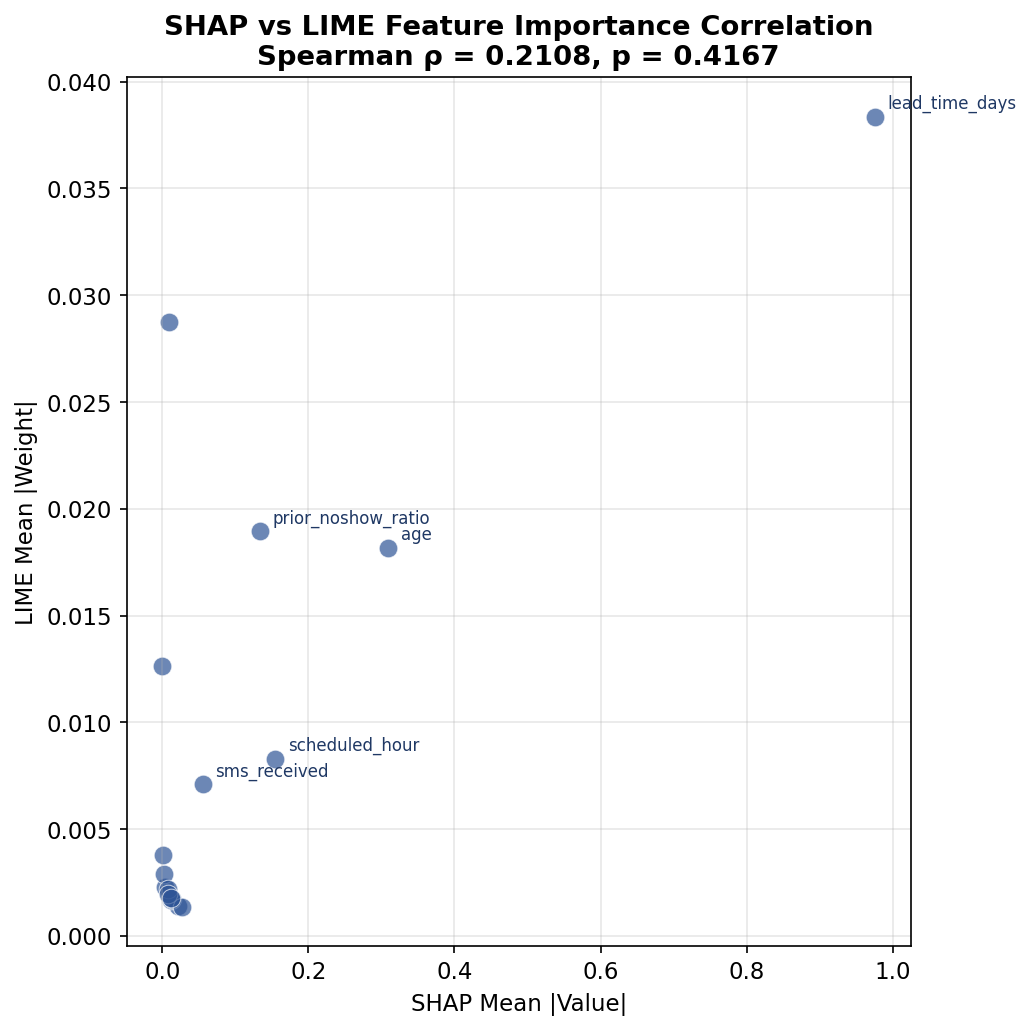

Figure saved: fig_20_shap_lime_scatter.png


In [ ]:
# ── Scatter plot: SHAP rank vs LIME rank ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(shap_vals_aligned, lime_vals_aligned,
           color='#2E5496', alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

# Label top 5 features
top5_idx = np.argsort(shap_vals_aligned)[-5:]
for i in top5_idx:
    ax.annotate(common_features[i],
                (shap_vals_aligned[i], lime_vals_aligned[i]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='#1F3864')

ax.set_xlabel('SHAP Mean |Value|')
ax.set_ylabel('LIME Mean |Weight|')
ax.set_title(f'SHAP vs LIME Feature Importance Correlation\n'
             f'Spearman ρ = {rho:.4f}, p = {pval:.4f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_20_shap_lime_scatter.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_20_shap_lime_scatter.png')

---
## 6. Key Findings Summary

In [ ]:
# ── Print findings summary ────────────────────────────────────────────────
print('=' * 65)
print('EXPLAINABILITY ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 65)

print('\n--- SHAP Results ---')
print(f'Top 3 features by SHAP importance:')
for i, row in shap_df.head(3).iterrows():
    print(f'  {i+1}. {row["Feature"]:30s} Mean |SHAP| = {row["Mean |SHAP|"]:.4f}')

hathaway_top = ['lead_time_days', 'prior_noshow_ratio']
our_top3     = shap_df['Feature'].head(3).tolist()
matches      = [f for f in hathaway_top if f in our_top3]
print(f'\nHathaway et al. (2025) top predictors: {hathaway_top}')
print(f'Matches in our top 3: {matches}')
if len(matches) == 2:
    print('Both Hathaway top predictors confirmed on the Brazilian dataset.')
elif len(matches) == 1:
    print('One Hathaway predictor confirmed. Differences may reflect dataset characteristics.')
else:
    print('Different predictors emerged — interesting cross-population finding.')

print('\n--- LIME Results ---')
print(f'Top 3 features by LIME importance:')
for i, row in lime_df.head(3).iterrows():
    print(f'  {i+1}. {row["Feature"]:30s} Mean |LIME| = {row["Mean |LIME|"]:.4f}')

print('\n--- SHAP vs LIME Agreement ---')
print(f'Spearman rank correlation : ρ = {rho:.4f}')
print(f'p-value                   : {pval:.6f}')
print(f'Interpretation            : {interpretation}')
print(f'Dissertation conclusion   : {conclusion}')

print('\n--- Figures Produced ---')
figs = [
    'fig_12_shap_importance_bar.png     — SHAP global feature importance',
    'fig_13_shap_beeswarm.png           — SHAP summary beeswarm',
    'fig_14_shap_dependence.png         — SHAP dependence plots (top 3)',
    'fig_15_shap_waterfall_high_risk.png — SHAP waterfall: high-risk patient',
    'fig_16_shap_waterfall_low_risk.png  — SHAP waterfall: low-risk patient',
    'fig_17_lime_importance_bar.png      — LIME average importance',
    'fig_18_lime_high_risk.png           — LIME individual: high-risk patient',
    'fig_19_shap_vs_lime_comparison.png  — Side-by-side bar comparison',
    'fig_20_shap_lime_scatter.png        — SHAP vs LIME scatter correlation',
]
for f in figs:
    print(f'  {f}')

print('\n=== NEXT STEP ===')
print('Notebook 04 — Demographic Fairness Audit')
print('Compare false negative rates across age, gender, and scholarship subgroups.')

EXPLAINABILITY ANALYSIS — KEY FINDINGS SUMMARY

--- SHAP Results ---
Top 3 features by SHAP importance:
  1. lead_time_days                 Mean |SHAP| = 0.9758
  2. age                            Mean |SHAP| = 0.3093
  3. scheduled_hour                 Mean |SHAP| = 0.1548

Hathaway et al. (2025) top predictors: ['lead_time_days', 'prior_noshow_ratio']
Matches in our top 3: ['lead_time_days']
One Hathaway predictor confirmed. Differences may reflect dataset characteristics.

--- LIME Results ---
Top 3 features by LIME importance:
  1. lead_time_days                 Mean |LIME| = 0.0384
  2. disability                     Mean |LIME| = 0.0287
  3. prior_noshow_ratio             Mean |LIME| = 0.0190

--- SHAP vs LIME Agreement ---
Spearman rank correlation : ρ = 0.2108
p-value                   : 0.416750
Interpretation            : POOR agreement — SHAP and LIME disagree substantially.
Dissertation conclusion   : Consistent with Bussmann et al. (2021) findings in finance.

--- Figures 

---
## Summary Table

| What was done | Detail |
|---|---|
| SHAP — global importance | Bar chart + beeswarm of all features |
| SHAP — dependence plots | Top 3 features showing direction of effect |
| SHAP — individual | Waterfall charts for one high-risk and one low-risk patient |
| LIME — average | Mean importance over 100 stratified predictions |
| LIME — individual | Explanation for high-risk patient |
| SHAP vs LIME comparison | Spearman ρ + side-by-side bar + scatter plot |
| Figures produced | 9 dissertation-ready figures (fig_12 to fig_20) |

**Original contribution:** First study to compare SHAP and LIME consistency on a no-show prediction model.  
**Reference:** Bussmann et al. (2021) — found disagreement in financial domain; this study extends to healthcare.